In [ ]:
# Install required libraries
!pip install -q -U diffusers transformers accelerate safetensors huggingface_hub

# Import libraries
import torch
from diffusers import DiffusionPipeline
from huggingface_hub import login
from google.colab import userdata
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 84.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# ============================================================
# Hugging Face Authentication
# ============================================================

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN not found. Please add your Hugging Face token "
        "in Google Colab Secrets."
    )

login(token=HF_TOKEN)

In [ ]:
# ============================================================
# Model Configuration
# ============================================================

# ONLY CHANGE THIS MODEL NAME
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"


In [ ]:
# ============================================================
# Device Configuration
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Model:", MODEL_ID)


Device: cuda
Model: stabilityai/stable-diffusion-xl-base-1.0


In [ ]:
# ============================================================
# Load Text-to-Image Pipeline
# ============================================================

pipe = DiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True
)

pipe = pipe.to(device)

print("Model loaded successfully!")

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
def generate_image(
    prompt,
    negative_prompt=None,
    num_inference_steps=30,
    guidance_scale=7.5,
    width=1024,
    height=1024,
    seed=None
):
    """
    Generate an image from a text prompt using Hugging Face
    Diffusers pipeline.
    """

    # Set seed for reproducible results
    generator = None

    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)

    # Generate image
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        width=width,
        height=height,
        generator=generator
    )

    image = result.images[0]

    # Display image
    display(image)

    return image

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


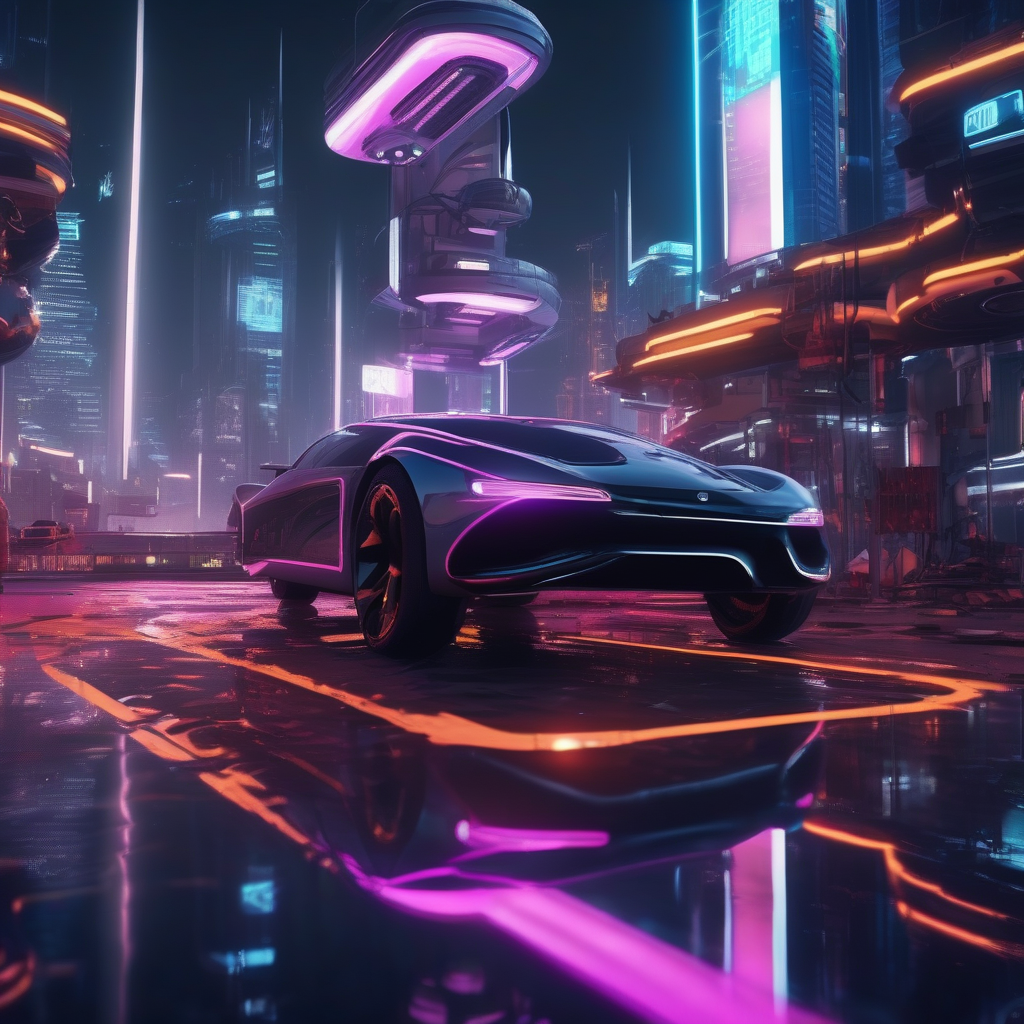

In [ ]:
prompt = """
A futuristic city at night, neon lights, flying cars,
cinematic atmosphere, highly detailed, realistic,
4K, professional photography
"""

image = generate_image(prompt)

  0%|          | 0/30 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


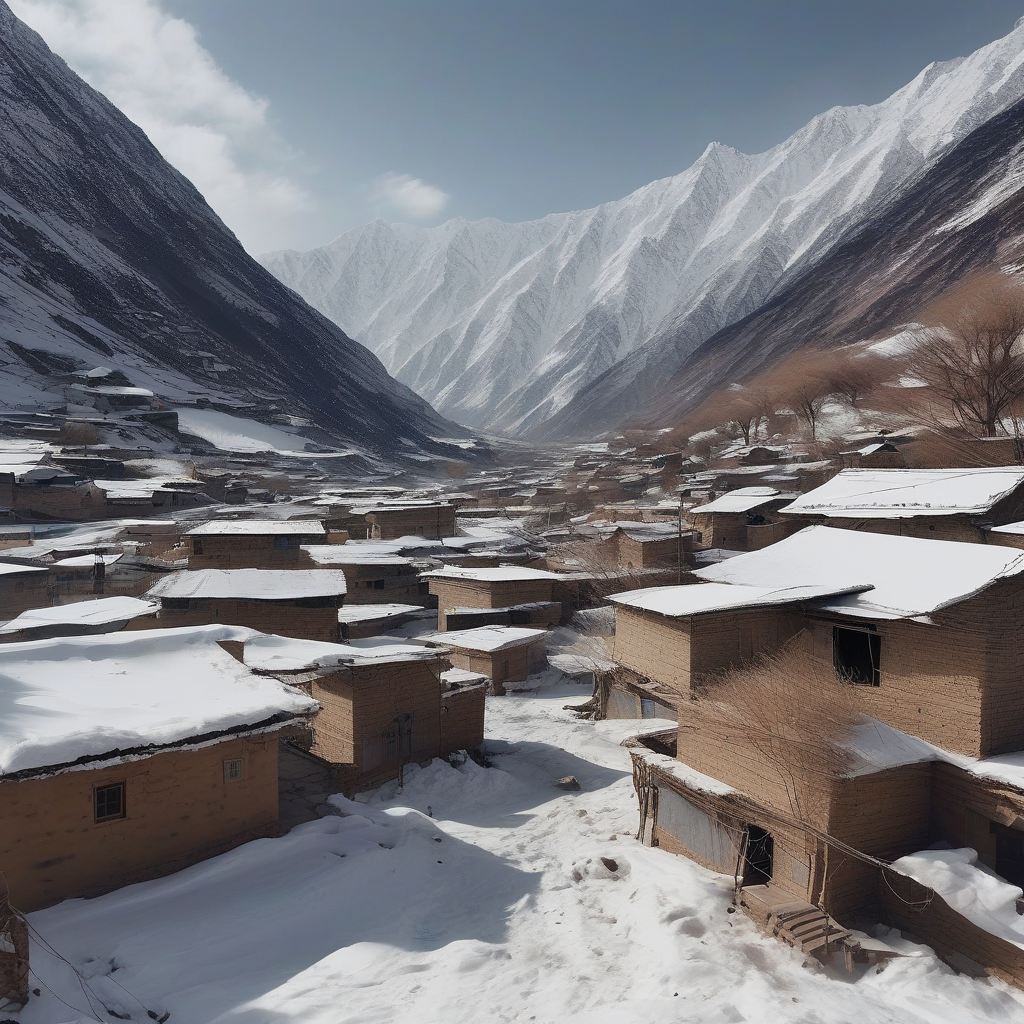

In [ ]:
image = generate_image(
    "A beautiful Pakistani mountain village surrounded by snow-covered mountains, cinematic photography, highly detailed"
)